In [1200]:
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score
from sklearn.tree import plot_tree

In [1201]:
df=pd.read_csv("train.csv")
df.head()

,id,belongs_to_collection,budget,genres,homepage,imdb_id,original_language,original_title,overview,popularity,...,release_date,runtime,spoken_languages,status,tagline,title,Keywords,cast,crew,revenue
0,1,"[{'id': 313576, 'name': 'Hot Tub Time Machine ...",14000000,"[{'id': 35, 'name': 'Comedy'}]",NaN,tt2637294,en,Hot Tub Time Machine 2,"When Lou, who has become the ""father of the In...",6.575393,...,2/20/15,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Laws of Space and Time are About to be Vio...,Hot Tub Time Machine 2,"[{'id': 4379, 'name': 'time travel'}, {'id': 9...","[{'cast_id': 4, 'character': 'Lou', 'credit_id...","[{'credit_id': '59ac067c92514107af02c8c8', 'de...",12314651
1,2,"[{'id': 107674, 'name': 'The Princess Diaries ...",40000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,tt0368933,en,The Princess Diaries 2: Royal Engagement,Mia Thermopolis is now a college graduate and ...,8.248895,...,8/6/04,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,It can take a lifetime to find true love; she'...,The Princess Diaries 2: Royal Engagement,"[{'id': 2505, 'name': 'coronation'}, {'id': 42...","[{'cast_id': 1, 'character': 'Mia Thermopolis'...","[{'credit_id': '52fe43fe9251416c7502563d', 'de...",95149435
2,3,NaN,3300000,"[{'id': 18, 'name': 'Drama'}]",http://sonyclassics.com/whiplash/,tt2582802,en,Whiplash,"Under the direction of a ruthless instructor, ...",64.299990,...,10/10/14,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The road to greatness can take you to the edge.,Whiplash,"[{'id': 1416, 'name': 'jazz'}, {'id': 1523, 'n...","[{'cast_id': 5, 'character': 'Andrew Neimann',...","[{'credit_id': '54d5356ec3a3683ba0000039', 'de...",13092000
3,4,NaN,1200000,"[{'id': 53, 'name': 'Thriller'}, {'id': 18, 'n...",http://kahaanithefilm.com/,tt1821480,hi,Kahaani,Vidya Bagchi (Vidya Balan) arrives in Kolkata ...,3.174936,...,3/9/12,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,NaN,Kahaani,"[{'id': 10092, 'name': 'mystery'}, {'id': 1054...","[{'cast_id': 1, 'character': 'Vidya Bagchi', '...","[{'credit_id': '52fe48779251416c9108d6eb', 'de...",16000000
4,5,NaN,0,"[{'id': 28, 'name': 'Action'}, {'id': 53, 'nam...",NaN,tt1380152,ko,마린보이,Marine Boy is the story of a former national s...,1.148070,...,2/5/09,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",Released,NaN,Marine Boy,NaN,"[{'cast_id': 3, 'character': 'Chun-soo', 'cred...","[{'credit_id': '52fe464b9251416c75073b43', 'de...",3923970


In [1202]:
df.shape

(3000, 23)

In [1203]:
df.describe()

,id,budget,popularity,runtime,revenue
count,3000.000000,3.000000e+03,3000.000000,2998.000000,3.000000e+03
mean,1500.500000,2.253133e+07,8.463274,107.856571,6.672585e+07
std,866.169729,3.702609e+07,12.104000,22.086434,1.375323e+08
min,1.000000,0.000000e+00,0.000001,0.000000,1.000000e+00
25%,750.750000,0.000000e+00,4.018053,94.000000,2.379808e+06
50%,1500.500000,8.000000e+06,7.374861,104.000000,1.680707e+07
75%,2250.250000,2.900000e+07,10.890983,118.000000,6.891920e+07
max,3000.000000,3.800000e+08,294.337037,338.000000,1.519558e+09


In [1204]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     3000 non-null   int64  
 1   belongs_to_collection  604 non-null    object 
 2   budget                 3000 non-null   int64  
 3   genres                 2993 non-null   object 
 4   homepage               946 non-null    object 
 5   imdb_id                3000 non-null   object 
 6   original_language      3000 non-null   object 
 7   original_title         3000 non-null   object 
 8   overview               2992 non-null   object 
 9   popularity             3000 non-null   float64
 10  poster_path            2999 non-null   object 
 11  production_companies   2844 non-null   object 
 12  production_countries   2945 non-null   object 
 13  release_date           3000 non-null   object 
 14  runtime                2998 non-null   float64
 15  spok

# Data preprocessing

In [1205]:
df.columns

Index(['id', 'belongs_to_collection', 'budget', 'genres', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'runtime', 'spoken_languages',
       'status', 'tagline', 'title', 'Keywords', 'cast', 'crew', 'revenue'],
      dtype='object')

columns='id', 'belongs_to_collection', 'budget', 'genres', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'runtime', 'spoken_languages',
       'status', 'tagline', 'title', 'Keywords', 'cast', 'crew', 'revenue'

In [1206]:
df.iloc[0]

id                                                                       1
belongs_to_collection    [{'id': 313576, 'name': 'Hot Tub Time Machine ...
budget                                                            14000000
genres                                      [{'id': 35, 'name': 'Comedy'}]
homepage                                                               NaN
imdb_id                                                          tt2637294
original_language                                                       en
original_title                                      Hot Tub Time Machine 2
overview                 When Lou, who has become the "father of the In...
popularity                                                        6.575393
poster_path                               /tQtWuwvMf0hCc2QR2tkolwl7c3c.jpg
production_companies     [{'name': 'Paramount Pictures', 'id': 4}, {'na...
production_countries     [{'iso_3166_1': 'US', 'name': 'United States o...
release_date             

In [1207]:
df['belongs_to_collection'].iloc[0]

"[{'id': 313576, 'name': 'Hot Tub Time Machine Collection', 'poster_path': '/iEhb00TGPucF0b4joM1ieyY026U.jpg', 'backdrop_path': '/noeTVcgpBiD48fDjFVic1Vz7ope.jpg'}]"

In [1208]:
df['belongs_to_collection'].values

array(["[{'id': 313576, 'name': 'Hot Tub Time Machine Collection', 'poster_path': '/iEhb00TGPucF0b4joM1ieyY026U.jpg', 'backdrop_path': '/noeTVcgpBiD48fDjFVic1Vz7ope.jpg'}]",
       "[{'id': 107674, 'name': 'The Princess Diaries Collection', 'poster_path': '/wt5AMbxPTS4Kfjx7Fgm149qPfZl.jpg', 'backdrop_path': '/zSEtYD77pKRJlUPx34BJgUG9v1c.jpg'}]",
       nan, ..., nan, nan, nan], dtype=object)

In [1209]:
df['genres'].values

array(["[{'id': 35, 'name': 'Comedy'}]",
       "[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'name': 'Drama'}, {'id': 10751, 'name': 'Family'}, {'id': 10749, 'name': 'Romance'}]",
       "[{'id': 18, 'name': 'Drama'}]", ...,
       "[{'id': 80, 'name': 'Crime'}, {'id': 28, 'name': 'Action'}, {'id': 9648, 'name': 'Mystery'}, {'id': 53, 'name': 'Thriller'}]",
       "[{'id': 35, 'name': 'Comedy'}, {'id': 10749, 'name': 'Romance'}]",
       "[{'id': 53, 'name': 'Thriller'}, {'id': 28, 'name': 'Action'}, {'id': 9648, 'name': 'Mystery'}]"],
      dtype=object)

In [1210]:
df['production_companies'].iloc[0]

"[{'name': 'Paramount Pictures', 'id': 4}, {'name': 'United Artists', 'id': 60}, {'name': 'Metro-Goldwyn-Mayer (MGM)', 'id': 8411}]"

In [1211]:
def extract_collection_features(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except:
            return pd.Series([None])
    
    
    if isinstance(x, list) and len(x) > 0:
        return pd.Series([                    
            x[0].get('name')       
        ])
    
    return pd.Series([None])

column created:has_collection

In [1212]:
df['collection_name']=df['belongs_to_collection'].apply(extract_collection_features)

In [1213]:
df['has_collection'] = df['collection_name'].apply(lambda x: 1 if x!=None  else 0)

In [1214]:
def extract_names(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except:
            return []
    
    if isinstance(x, list):
        return [i.get('name') for i in x if isinstance(i, dict) and 'name' in i]
    
    return []

In [1215]:
df['genres_list']=df['genres'].apply(extract_names)

In [1216]:
df['genre_count'] = df['genres_list'].apply(len)

In [1217]:
df['has_homepage'] = df['homepage'].notnull().astype(int)

In [1218]:
df['original_language'].value_counts()

original_language
en    2575
fr      78
ru      47
es      43
hi      42
ja      37
it      24
cn      20
ko      20
zh      19
de      18
ta      16
sv       8
nl       6
pt       6
fa       5
da       5
ro       4
hu       3
tr       3
no       2
ml       2
pl       2
te       2
fi       2
ur       1
he       1
el       1
ar       1
nb       1
vi       1
mr       1
cs       1
sr       1
bn       1
id       1
Name: count, dtype: int64

In [1219]:
top_langs = df['original_language'].value_counts().index[:5]

df['original_language'] = df['original_language'].apply(
    lambda x: x if x in top_langs else 'other'
)

In [1220]:
df = pd.get_dummies(df, columns=['original_language'], drop_first=True,dtype=int)

In [1221]:
df['overview_length'] = df['overview'].fillna('').apply(len)
df['overview_word_count'] = df['overview'].fillna('').apply(lambda x: len(x.split()))

In [1222]:
df['company_names'] = df['production_companies'].apply(extract_names)

In [1223]:
all_companies = df['company_names'].explode()

freq = all_companies.value_counts()

df['company_score'] = df['company_names'].apply(
    lambda x: sum(freq.get(i, 0) for i in x)
)

In [1224]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_dayofweek'] = df['release_date'].dt.dayofweek

/var/folders/xw/5yjdwh314qq6ntp9fy6rpyfm0000gn/T/ipykernel_18495/1937282013.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')


In [1225]:
df['runtime'].fillna(df['runtime'].median(), inplace=True)

/var/folders/xw/5yjdwh314qq6ntp9fy6rpyfm0000gn/T/ipykernel_18495/530401232.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['runtime'].fillna(df['runtime'].median(), inplace=True)


In [1226]:
df['keyword_names'] = df['Keywords'].apply(extract_names)

In [1227]:
all_keywords = df['keyword_names'].explode()
freq = all_keywords.value_counts()

df['keyword_score'] = df['keyword_names'].apply(
    lambda x: sum(freq.get(i, 0) for i in x)
)

In [1228]:
df['cast_names'] = df['cast'].apply(extract_names)

In [1229]:
all_cast = df['cast_names'].explode()

In [1230]:
freq = all_cast.value_counts()

df['cast_score'] = df['cast_names'].apply(
    lambda x: sum(freq.get(i, 0) for i in x)
)

In [1231]:
def extract_director(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except:
            return None
    
    if isinstance(x, list):
        for i in x:
            if isinstance(i, dict) and i.get('job') == 'Director':
                return i.get('name')   # ✅ string
    
    return None

In [1232]:
df['director'] = df['crew'].apply(extract_director)

In [1233]:
freq = df['director'].value_counts()
df['director_score'] = df['director'].map(freq)

In [1234]:
df.drop(columns=['belongs_to_collection','id','collection_name','genres_list','genres','homepage', 'imdb_id','original_title','overview','poster_path','production_companies','company_names','production_countries', 'release_date','status','tagline','title','keyword_names','Keywords','cast_names','cast','crew','director',], inplace=True)

In [1235]:
df.head()

,budget,popularity,runtime,spoken_languages,revenue,has_collection,genre_count,has_homepage,original_language_es,original_language_fr,...,original_language_ru,overview_length,overview_word_count,company_score,release_year,release_month,release_dayofweek,keyword_score,cast_score,director_score
0,14000000,6.575393,93.0,"[{'iso_639_1': 'en', 'name': 'English'}]",12314651,1,1,0,0,0,...,0,155,29,289,2015,2,4,227,101,3.0
1,40000000,8.248895,113.0,"[{'iso_639_1': 'en', 'name': 'English'}]",95149435,1,4,0,0,0,...,0,393,69,62,2004,8,4,34,95,6.0
2,3300000,64.299990,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",13092000,0,1,1,0,0,...,0,130,21,26,2014,10,4,161,108,1.0
3,1200000,3.174936,122.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",16000000,0,2,1,0,0,...,0,581,106,0,2012,3,4,49,11,1.0
4,0,1.148070,118.0,"[{'iso_639_1': 'ko', 'name': '한국어/조선말'}]",3923970,0,2,0,0,0,...,0,168,32,0,2009,2,3,0,5,1.0


# EDA

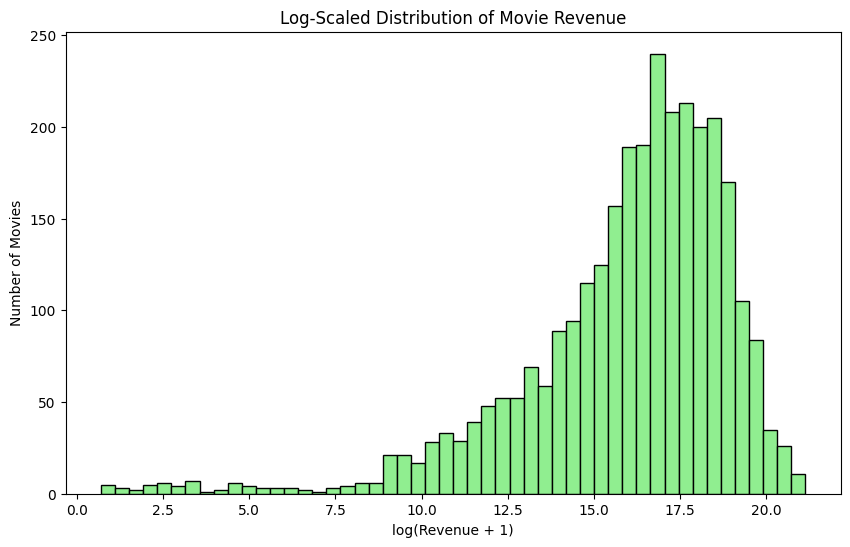

In [1236]:
# revenue histogram
plt.figure(figsize=(10,6))
plt.hist(np.log1p(df['revenue']), bins=50, color='lightgreen', edgecolor='black')
plt.title('Log-Scaled Distribution of Movie Revenue')
plt.xlabel('log(Revenue + 1)')
plt.ylabel('Number of Movies')
plt.show()

● Majority of movies have moderate to high revenue
● Few movies have very low revenue, which appear as a small tail on the left side of the histogram

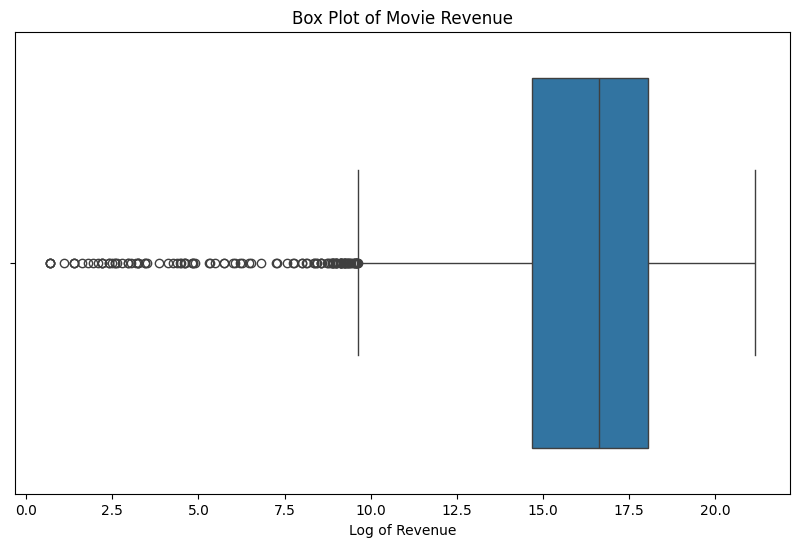

In [1237]:
plt.figure(figsize=(10,6))
sns.boxplot(x=np.log1p(df['revenue']))  # log1p avoids log(0)
plt.xlabel('Log of Revenue')
plt.title('Box Plot of Movie Revenue')
plt.show()

# Univariate Analysis 

In [1238]:
df.columns

Index(['budget', 'popularity', 'runtime', 'spoken_languages', 'revenue',
       'has_collection', 'genre_count', 'has_homepage', 'original_language_es',
       'original_language_fr', 'original_language_hi',
       'original_language_other', 'original_language_ru', 'overview_length',
       'overview_word_count', 'company_score', 'release_year', 'release_month',
       'release_dayofweek', 'keyword_score', 'cast_score', 'director_score'],
      dtype='object')

'budget', 'popularity', 'runtime', 'revenue', 'has_collection',
'genre_count', 'has_homepage', 'original_language_es',
'original_language_fr', 'original_language_hi',
'original_language_other', 'original_language_ru', 'overview_length',
'overview_word_count', 'company_score', 'release_year', 'release_month',
 'release_dayofweek', 'keyword_score', 'cast_score', 'director_score'

# Summary Statistics

In [1239]:
# Numerical summary
num_cols = ['budget','popularity','runtime','revenue','overview_length',
            'overview_word_count','company_score','keyword_score','cast_score','director_score']
df[num_cols].describe()

,budget,popularity,runtime,revenue,overview_length,overview_word_count,company_score,keyword_score,cast_score,director_score
count,3.000000e+03,3000.000000,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,2984.000000
mean,2.253133e+07,8.463274,107.854000,6.672585e+07,307.805667,52.535333,66.811667,117.632667,69.977000,2.534853
std,3.702609e+07,12.104000,22.079293,1.375323e+08,167.023568,28.383328,78.081900,119.550968,51.426919,2.009563
min,0.000000e+00,0.000001,0.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000e+00,4.018053,94.000000,2.379808e+06,178.000000,31.000000,4.000000,28.000000,31.000000,1.000000
50%,8.000000e+06,7.374861,104.000000,1.680707e+07,285.000000,49.000000,30.000000,82.000000,60.000000,2.000000
75%,2.900000e+07,10.890983,118.000000,6.891920e+07,395.250000,68.000000,102.000000,175.000000,96.000000,3.000000
max,3.800000e+08,294.337037,338.000000,1.519558e+09,1007.000000,177.000000,375.000000,1259.000000,461.000000,11.000000


In [1240]:
cat_cols = ['has_collection','has_homepage','original_language_es','original_language_fr',
            'original_language_hi','original_language_other','original_language_ru','genre_count']

df[cat_cols].describe()

,has_collection,has_homepage,original_language_es,original_language_fr,original_language_hi,original_language_other,original_language_ru,genre_count
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000
mean,0.201333,0.315333,0.014333,0.026000,0.01400,0.071667,0.015667,2.503667
std,0.401063,0.464726,0.118881,0.159162,0.11751,0.257978,0.124203,1.117021
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,2.000000
50%,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,2.000000
75%,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000,0.000000,3.000000
max,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,7.000000


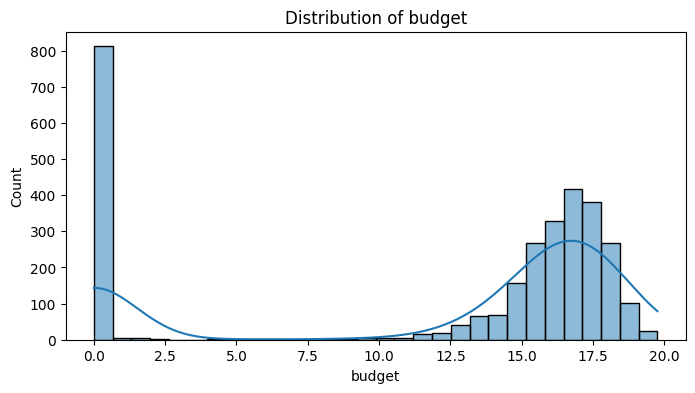

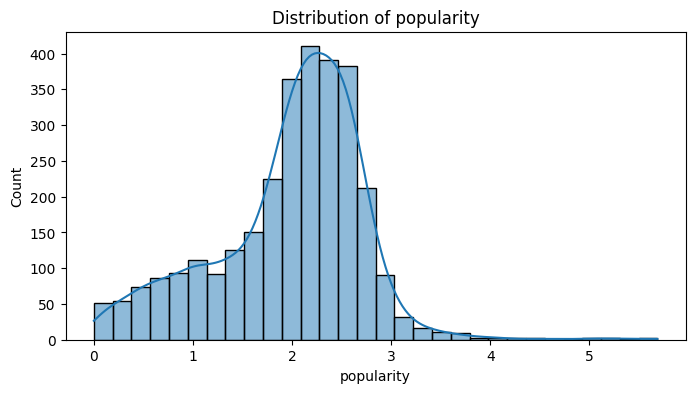

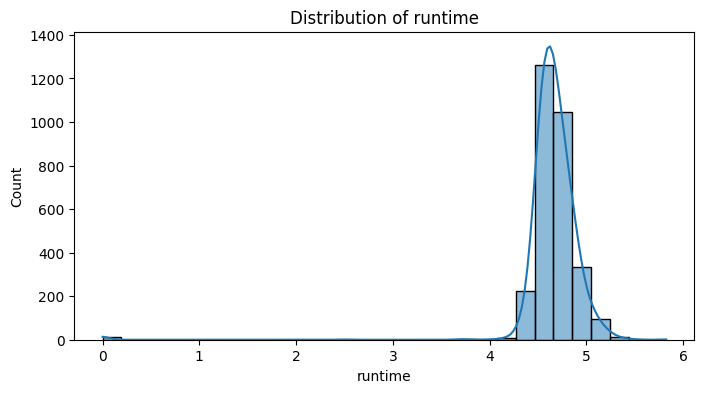

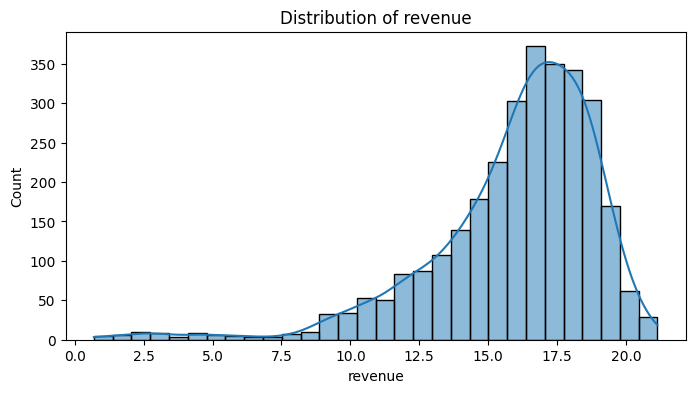

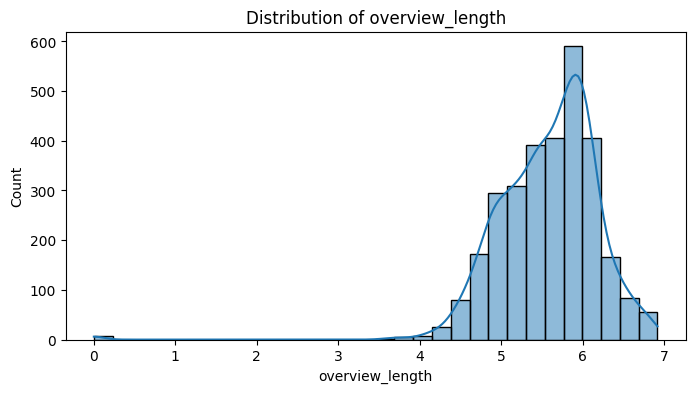

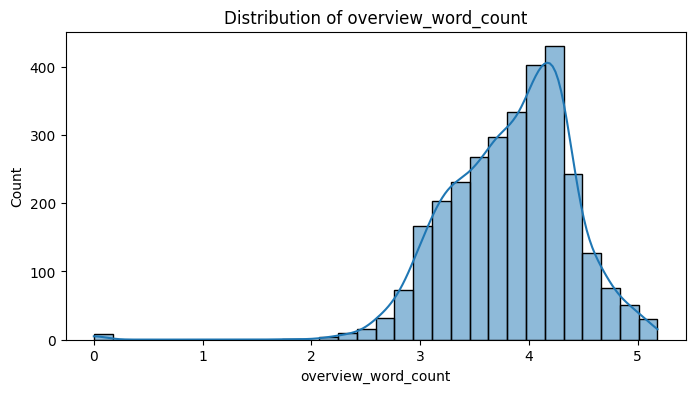

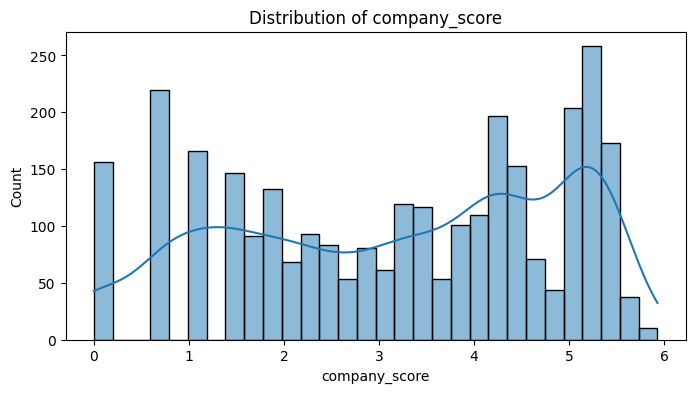

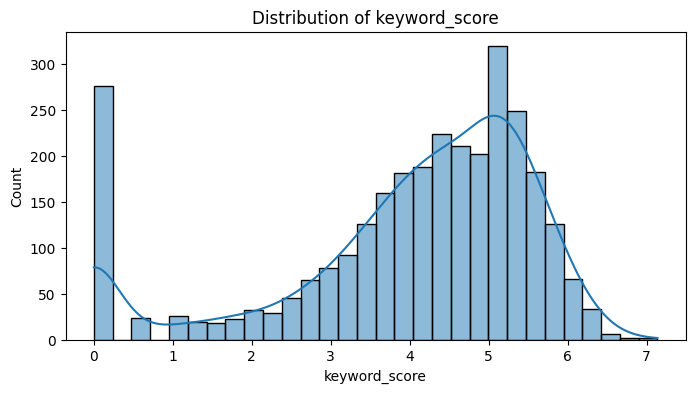

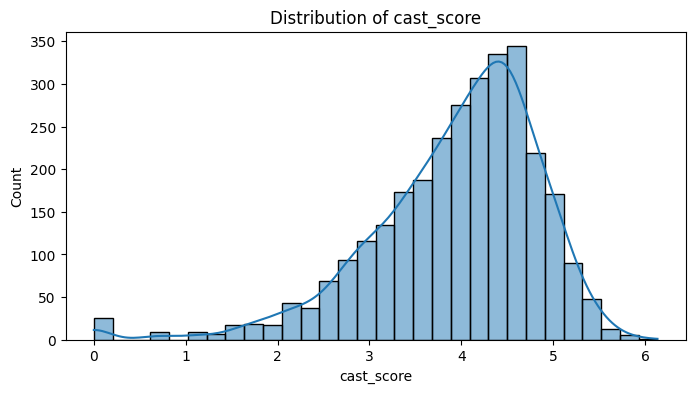

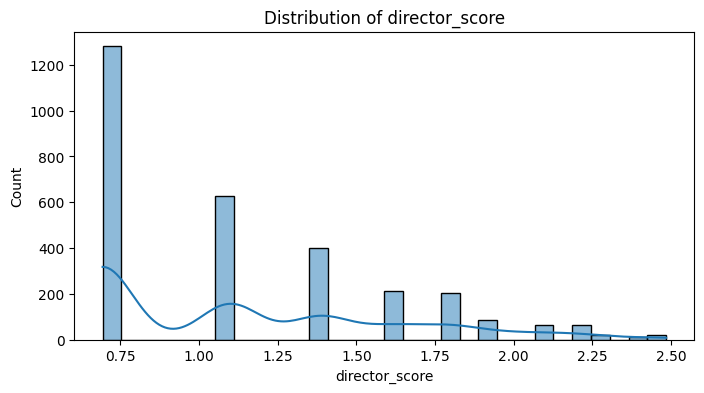

In [1241]:
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(np.log1p(df[col]), kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.show()

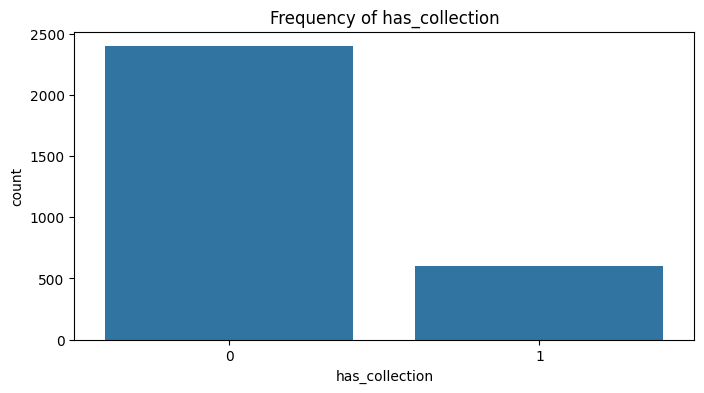

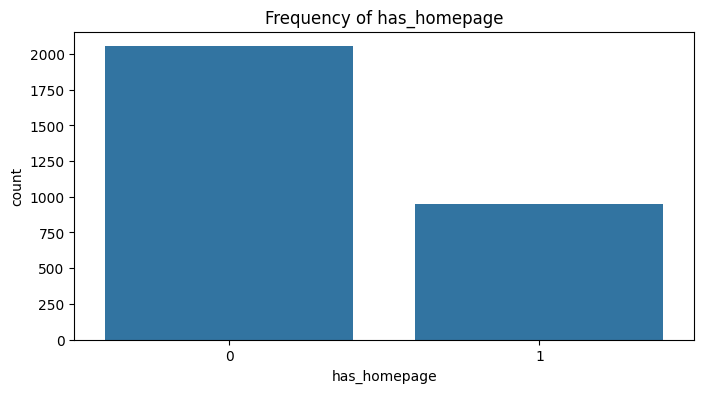

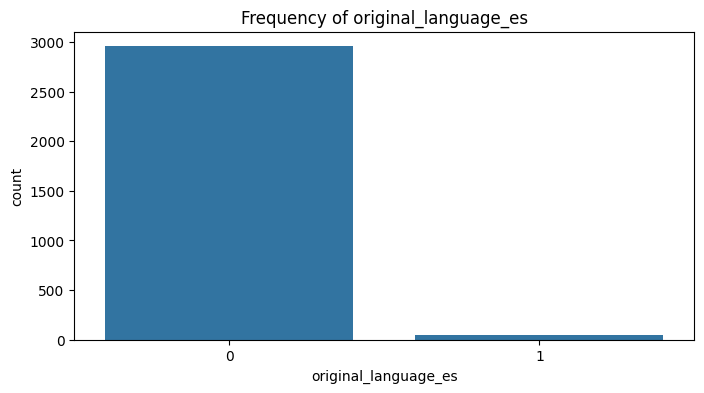

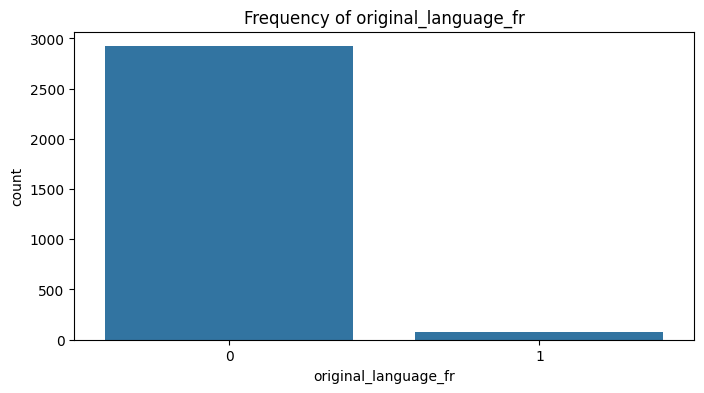

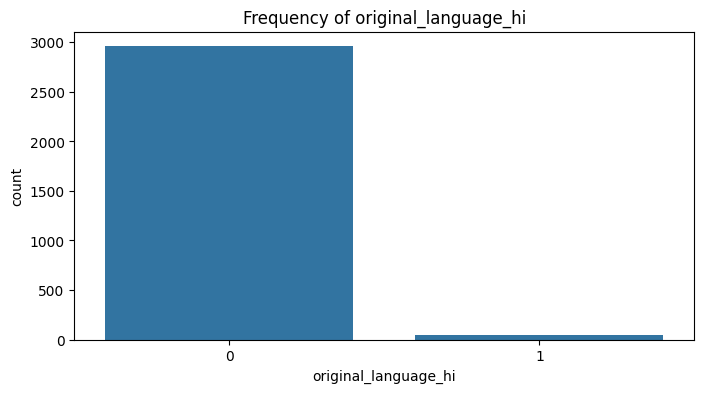

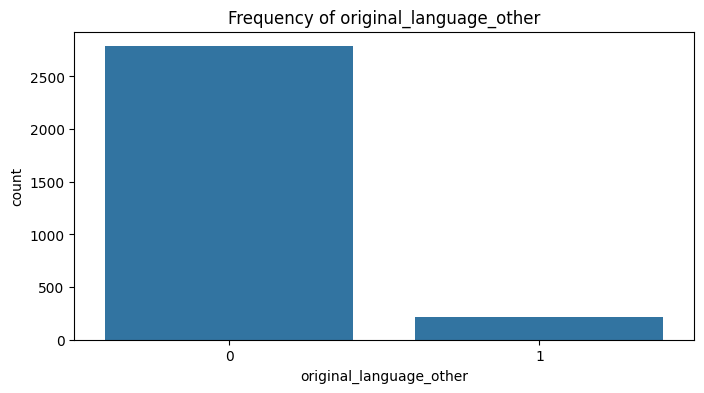

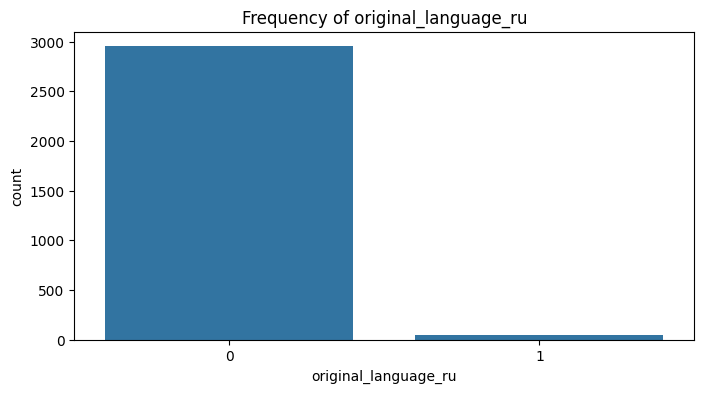

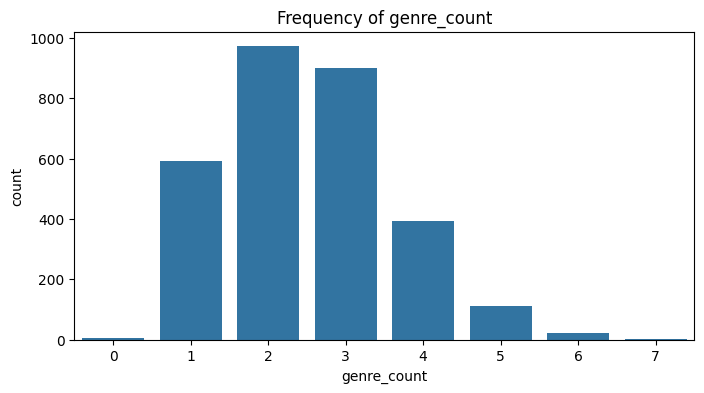

In [1242]:
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col])
    plt.title(f'Frequency of {col}')
    plt.show()

# Bivariate Analysis 

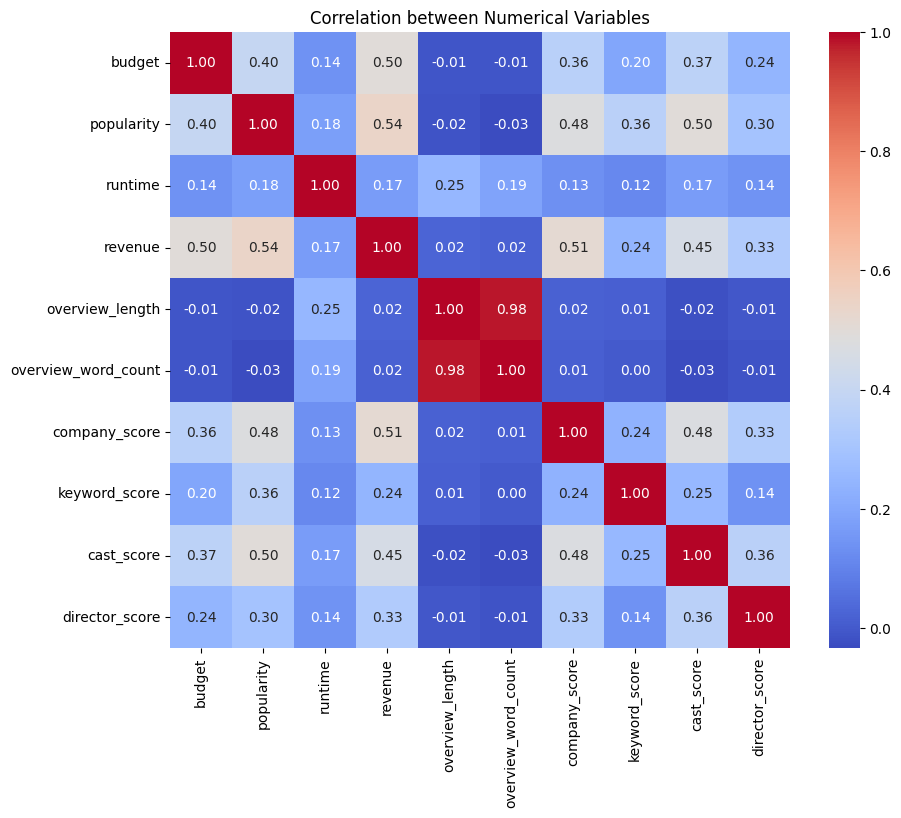

In [1243]:
plt.figure(figsize=(10,8))
sns.heatmap( np.log1p(df[num_cols]).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation between Numerical Variables")
plt.show()

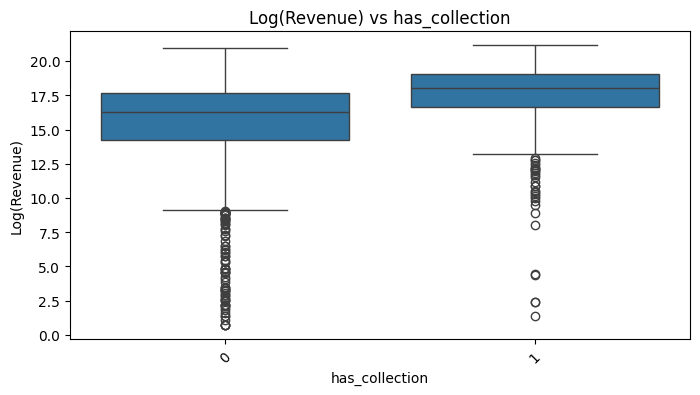

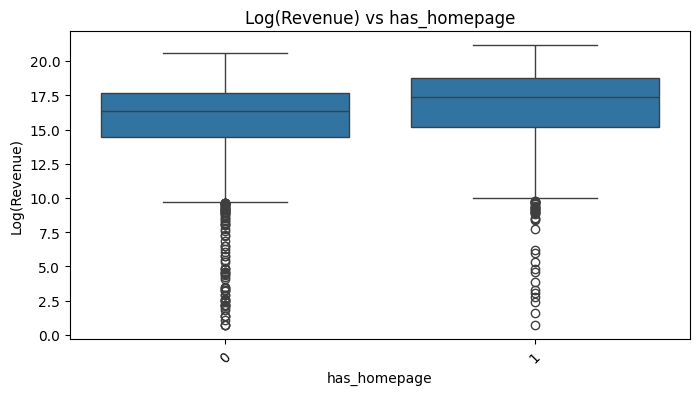

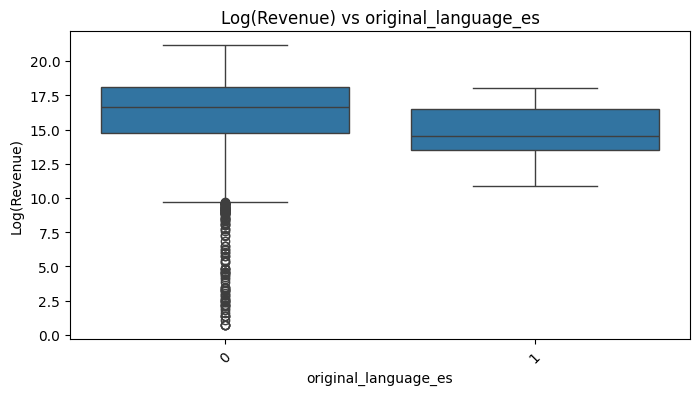

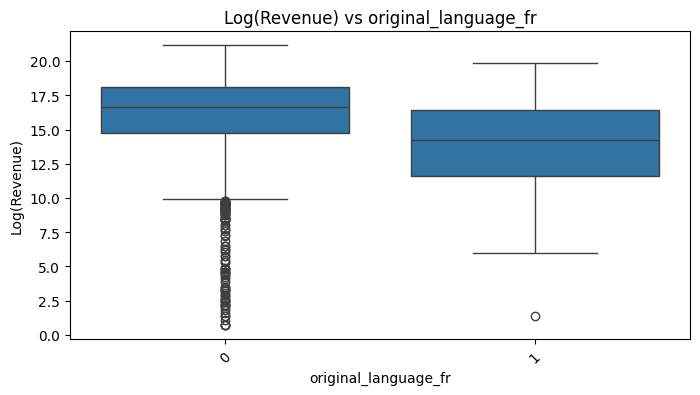

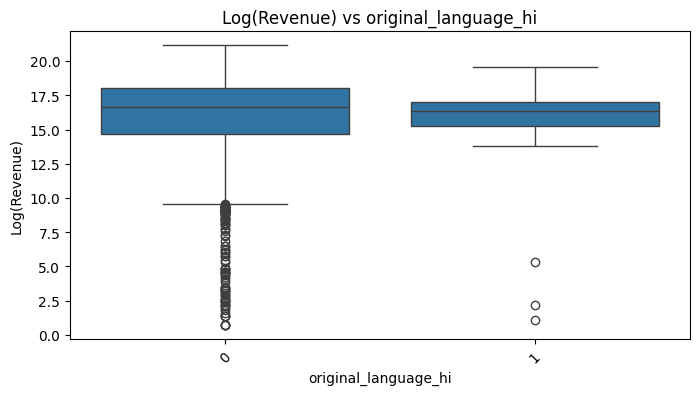

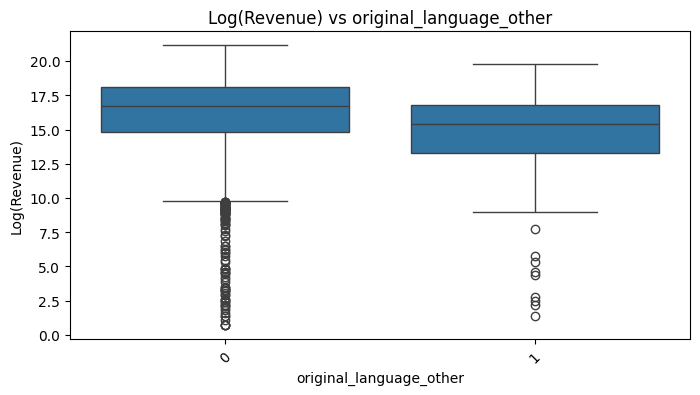

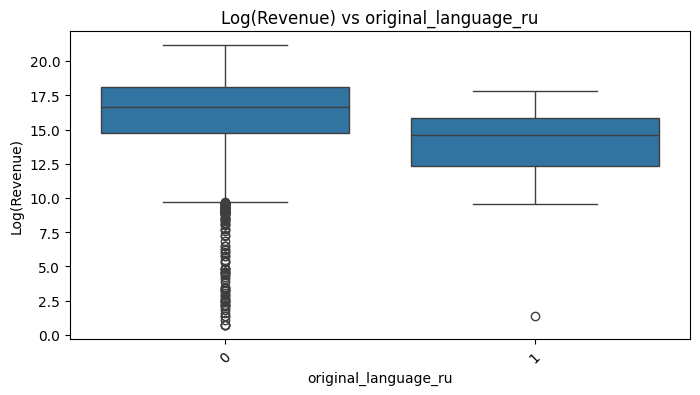

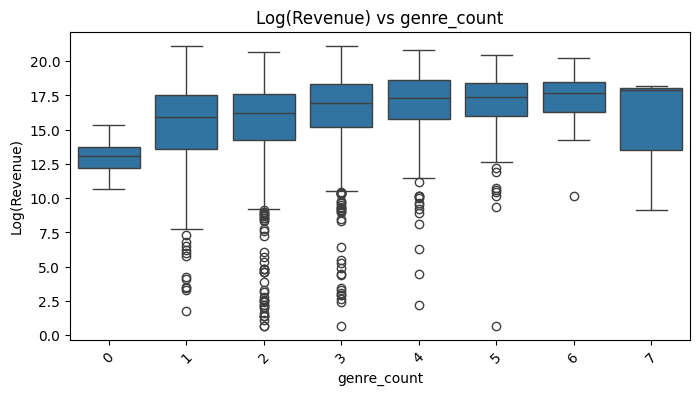

In [1244]:
target = 'revenue'

for col in cat_cols:
    plt.figure(figsize=(8,4))
    # Use log scale for skewed revenue
    sns.boxplot(x=col, y=np.log1p(df[target]), data=df)
    plt.title(f'Log(Revenue) vs {col}')
    plt.ylabel('Log(Revenue)')
    plt.xticks(rotation=45)
    plt.show()

In [1245]:
subset_cols = ['budget','popularity','runtime','revenue','cast_score','director_score']

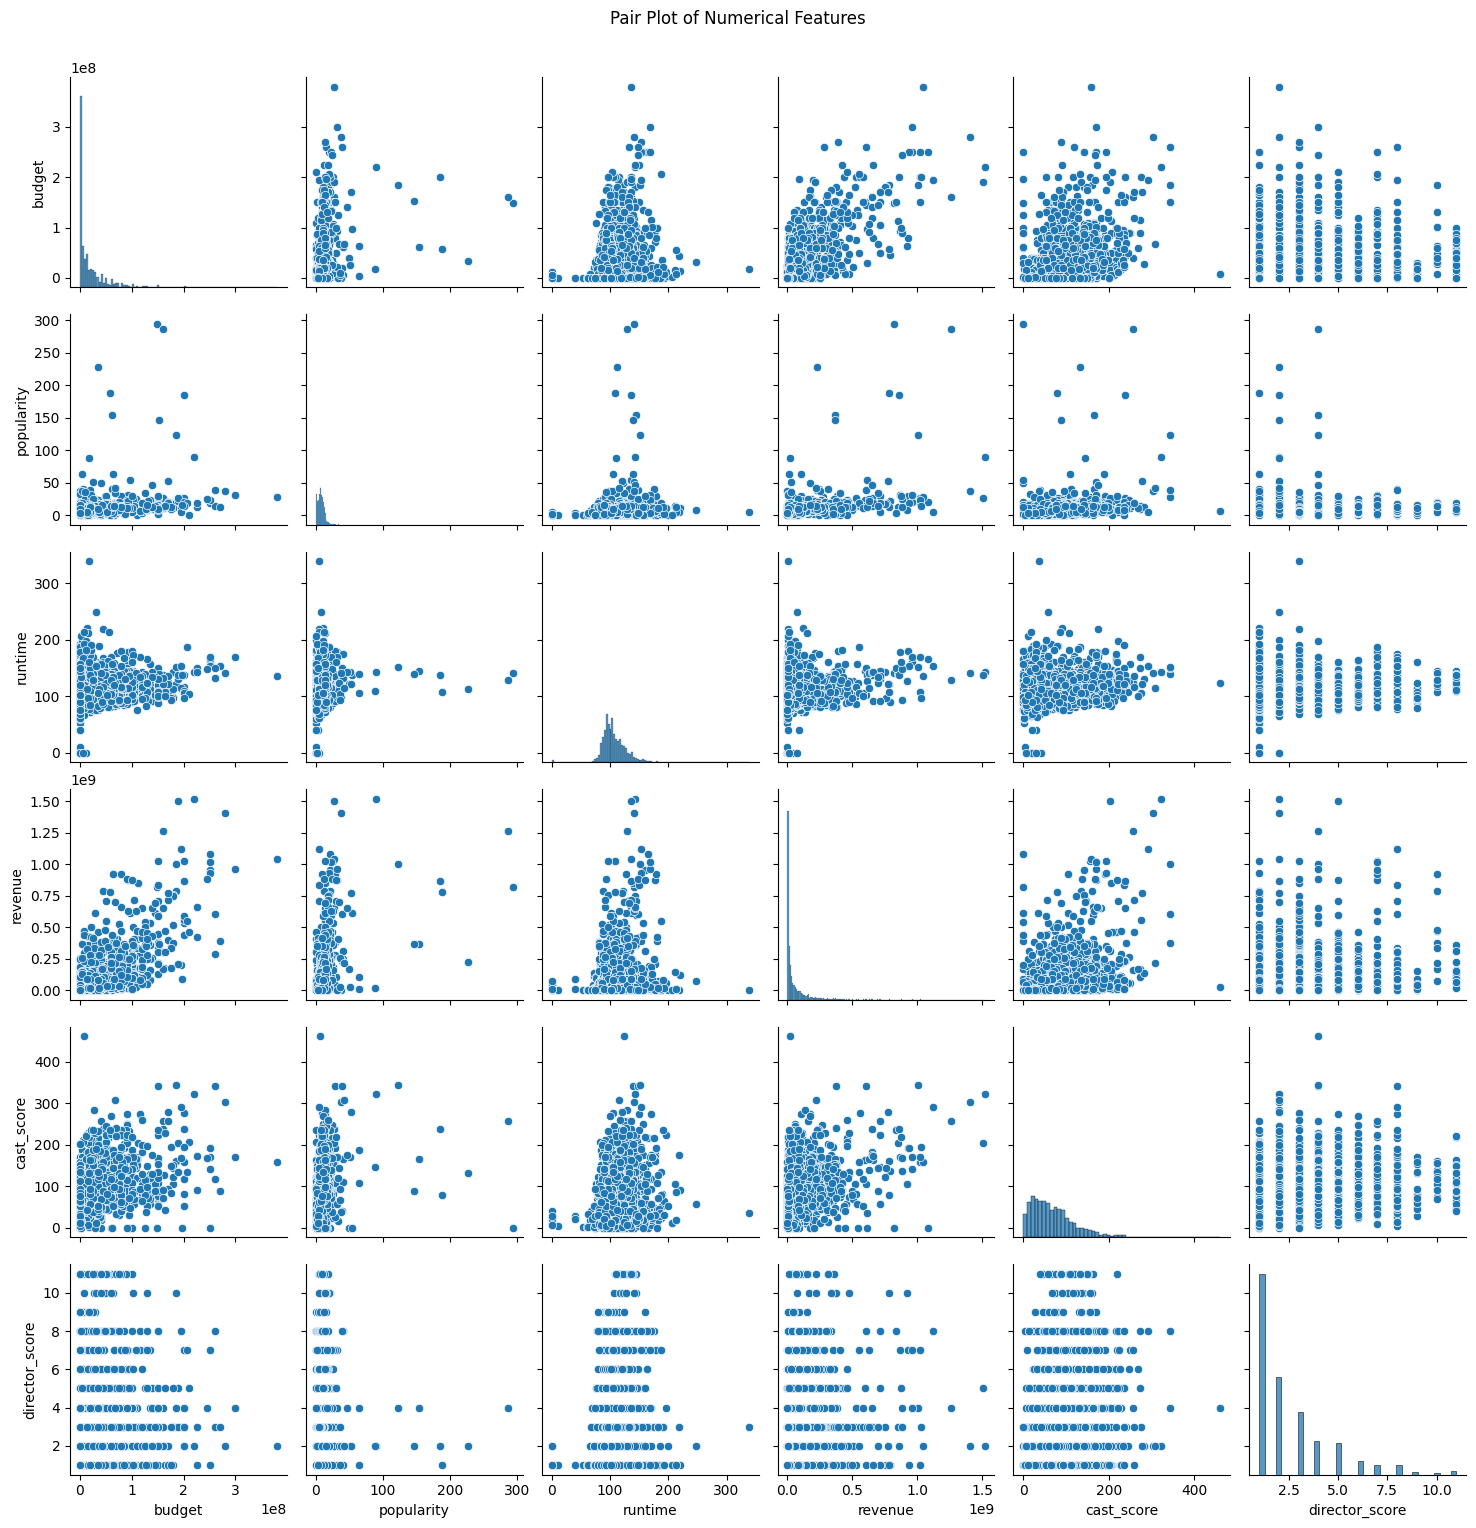

In [1246]:
sns.pairplot(df[subset_cols])
plt.suptitle("Pair Plot of Numerical Features", y=1.02)
plt.show()

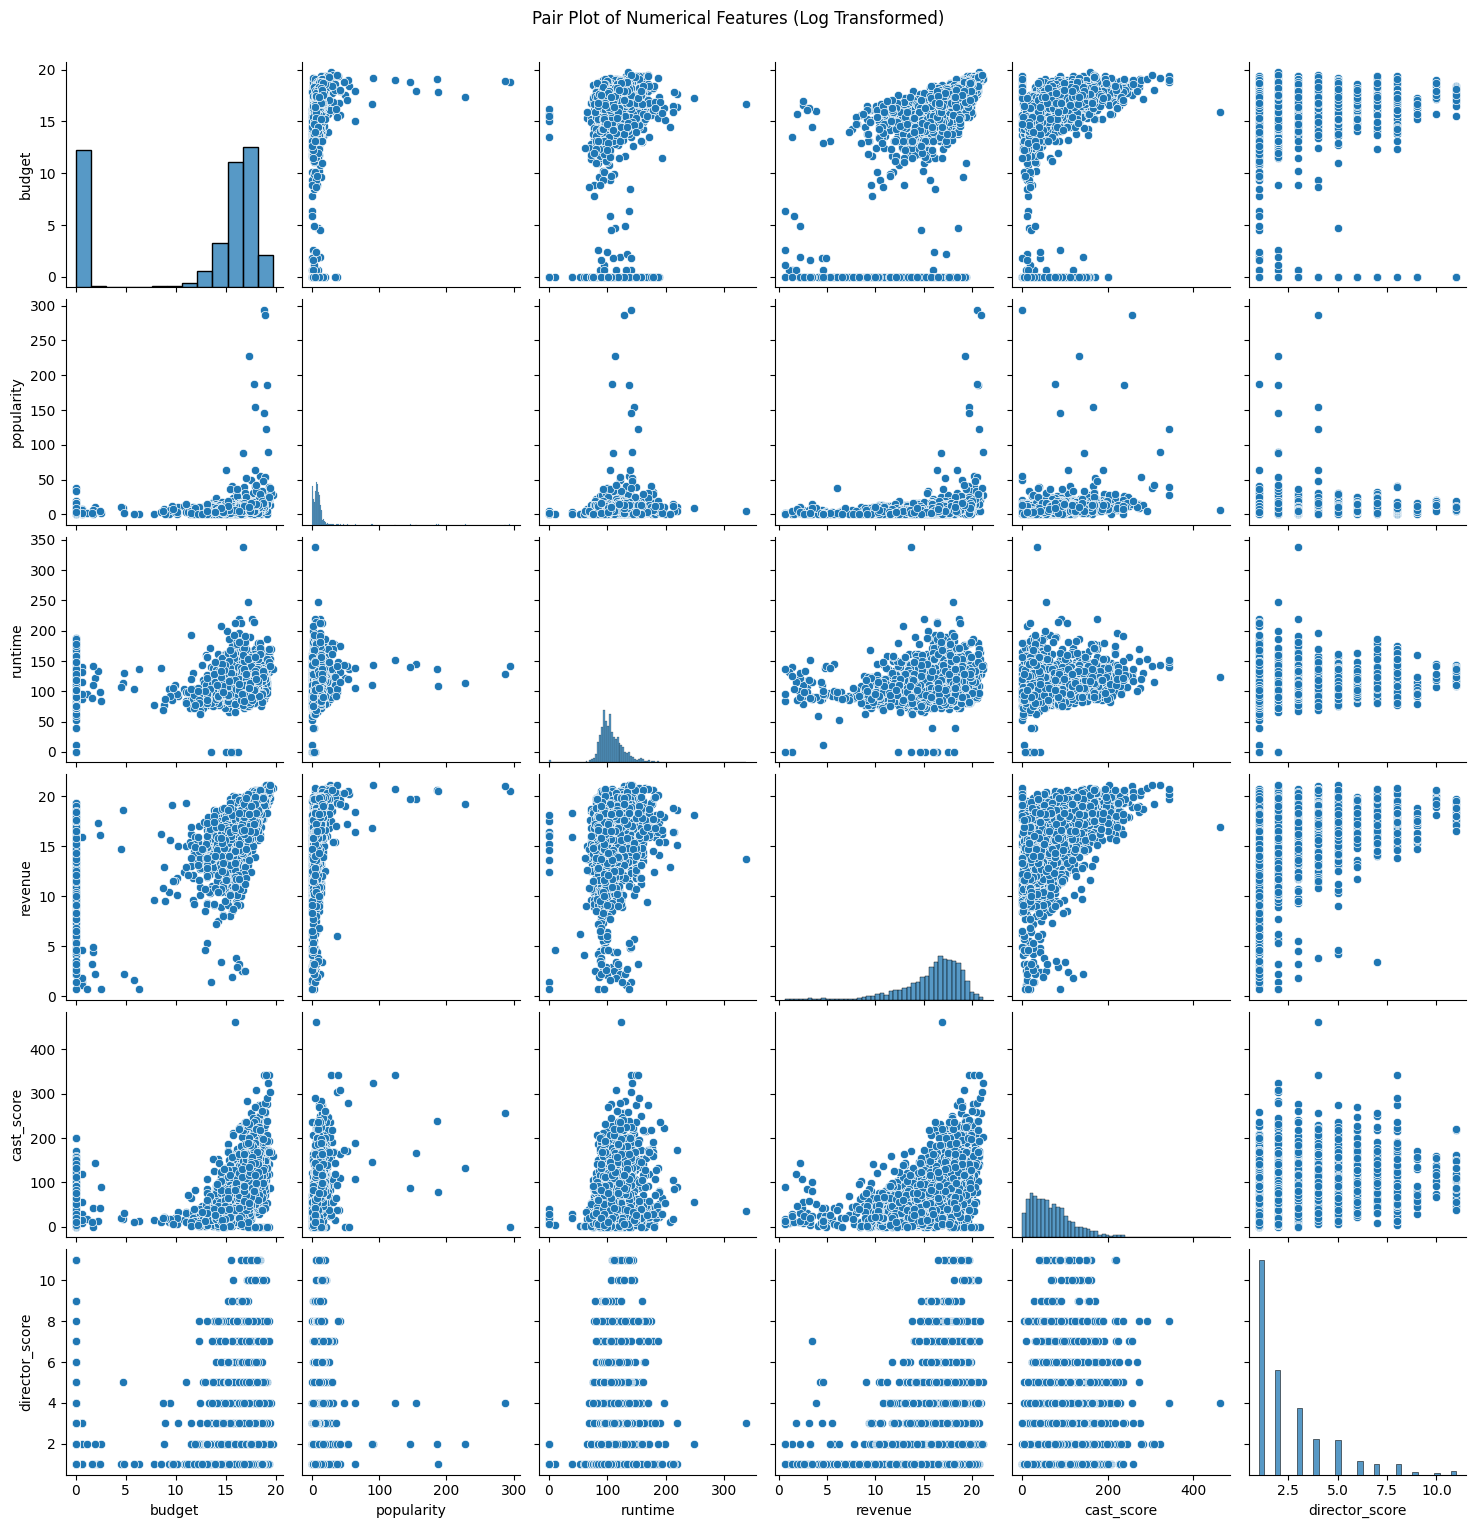

In [1247]:
df_log = df[subset_cols].copy()
df_log['revenue'] = np.log1p(df_log['revenue'])
df_log['budget'] = np.log1p(df_log['budget'])

sns.pairplot(df_log)
plt.suptitle("Pair Plot of Numerical Features (Log Transformed)", y=1.02)
plt.show()

# feature engineering

## feature transformation

In [1248]:
skewness = df[num_cols].skew()

print(skewness)

budget                  3.103530
popularity             14.377407
runtime                 1.018273
revenue                 4.542285
overview_length         1.148699
overview_word_count     1.145058
company_score           1.106804
keyword_score           1.906456
cast_score              1.344278
director_score          1.693568
dtype: float64


In [1249]:
df['log_budget'] = np.log1p(df['budget'])
df['log_revenue'] = np.log1p(df['revenue'])
df['log_popularity'] = np.log1p(df['popularity'])
df['log_keyword_score'] = np.log1p(df['keyword_score'])
df['log_director_score'] = np.log1p(df['director_score'])
df['log_company_score'] = np.log1p(df['company_score'])

In [1250]:
df['sqrt_cast_score'] = np.sqrt(df['cast_score'])
df['runtime'] = df['runtime'].replace(0, np.nan)
df['runtime_log'] = np.log1p(df['runtime'])

In [1251]:
skewed_cols = ['log_budget','log_revenue','log_popularity','log_keyword_score','log_director_score',
               'sqrt_cast_score','runtime_log']
print(df[skewed_cols].skew())

log_budget           -0.900065
log_revenue          -1.650536
log_popularity       -0.423864
log_keyword_score    -1.170916
log_director_score    0.777065
sqrt_cast_score       0.187525
runtime_log           0.001568
dtype: float64


In [1252]:
drop_col=['budget','revenue','popularity','keyword_score','cast_score','runtime']
df.drop(columns=drop_col,inplace=True)

In [1253]:
df['avg_word_length'] = df['overview_length'] / df['overview_word_count']
df = df.drop(columns=['overview_length', 'overview_word_count'])

'log_budget',	'log_revenue',	'log_popularity'	'log_keyword_score',	'log_director_score' , 'sqrt_cast_score',	'sqrt_runtime',  'avg_word_length'

log_keyword_score,sqrt_runtime for dropping consideration

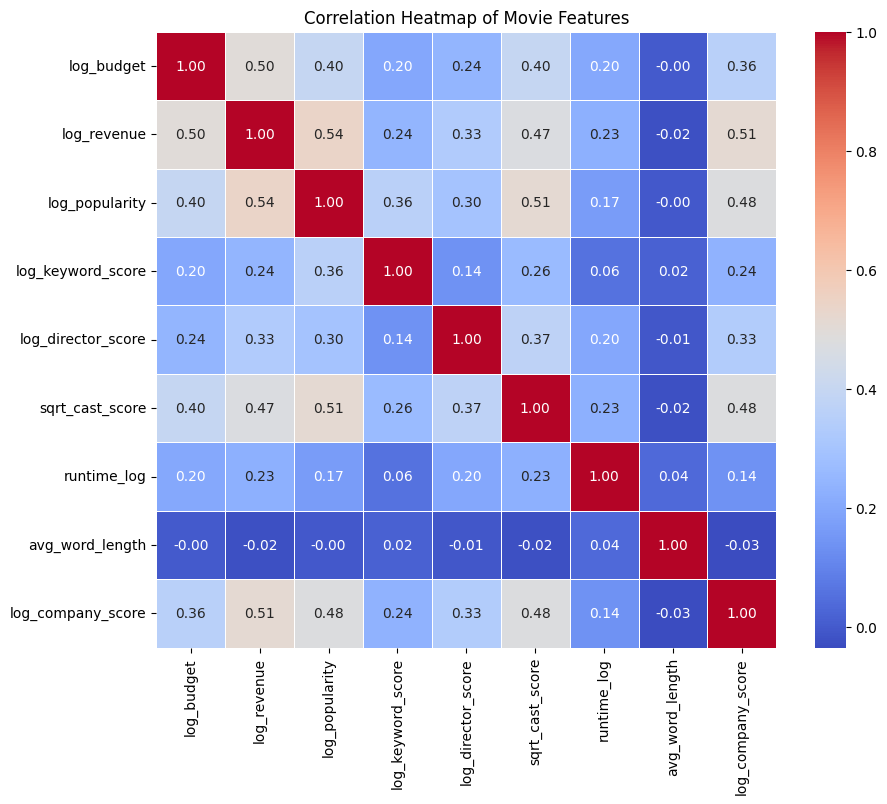

In [1254]:
cols = [
    'log_budget', 'log_revenue', 'log_popularity', 
    'log_keyword_score', 'log_director_score', 
    'sqrt_cast_score', 'runtime_log', 'avg_word_length','log_company_score'
]

# Compute correlation matrix
corr_matrix = df[cols].corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Movie Features")
plt.show()

In [1255]:
df = df.drop(columns=['avg_word_length'])

In [1256]:
#cat col trans formation
target = 'log_revenue'

In [1257]:
for col in cat_cols:
    pivot = pd.pivot_table(
        df,
        values=target,
        index=col,
        aggfunc='mean'
    )
    print(f"\nPivot for {col}:\n", pivot)


Pivot for has_collection:
                 log_revenue
has_collection             
0                 15.567722
1                 17.525986

Pivot for has_homepage:
               log_revenue
has_homepage             
0               15.664668
1               16.607538

Pivot for original_language_es:
                       log_revenue
original_language_es             
0                       15.981123
1                       14.645972

Pivot for original_language_fr:
                       log_revenue
original_language_fr             
0                       16.021782
1                       13.721944

Pivot for original_language_hi:
                       log_revenue
original_language_hi             
0                       15.970197
1                       15.383697

Pivot for original_language_other:
                          log_revenue
original_language_other             
0                          16.057360
1                          14.726564

Pivot for original_language_ru:
  

In [1258]:
corr, p = pointbiserialr(df['has_collection'], df['log_revenue'])

print("Correlation:", corr)
print("P-value:", p)

Correlation: 0.2565527363245794
P-value: 2.680284671303395e-46


In [1259]:
drop_cols = [
    'original_language_es',
    'original_language_fr',
    'original_language_hi',
    'original_language_ru',
    'original_language_other'
]
df = df.drop(columns=drop_cols)

In [1260]:
df['movie_age'] = 2026 - df['release_year']
df['movie_age'] = df['movie_age'].clip(lower=0)  # remove negatives
df['movie_age_log'] = np.log1p(df['movie_age'])

In [1261]:
df['is_peak_season'] = df['release_month'].isin([5,6,7,11,12]).astype(int)

In [1262]:
df['is_friday_release'] = (df['release_dayofweek'] == 4).astype(int)

In [1263]:
df['is_english'] = (df['spoken_languages'] == 'en').astype(int)
df = df.drop(columns=['spoken_languages','director_score','company_score','release_year','release_month','release_dayofweek'])

## feature creation

In [1265]:
df['budget_popularity'] = df['log_budget'] * df['log_popularity']
df['collection_popularity'] = df['has_collection'] * df['log_popularity']
df['company_director'] = df['log_company_score'] * df['log_director_score']

In [1266]:
df['genre_count_sq'] = df['genre_count'] ** 2
df['movie_age_log'] = np.sqrt(df['movie_age'])

In [1267]:
df = df.drop(columns=['log_budget','genre_count','log_popularity','movie_age','has_collection','log_company_score','log_director_score'])

In [1268]:
df.skew()

has_homepage             0.795264
log_revenue             -1.650536
log_keyword_score       -1.170916
sqrt_cast_score          0.187525
runtime_log              0.001568
movie_age_log           -1.147088
is_peak_season           0.474356
is_friday_release        0.225531
is_english               0.000000
budget_popularity       -0.069996
collection_popularity    1.849117
company_director         0.834187
genre_count_sq           1.664969
dtype: float64

In [1269]:
drop_cols = ['is_english']

df = df.drop(columns=drop_cols)

In [1270]:
X = df.drop(columns=['log_revenue'])  
y = df['log_revenue']   

In [1271]:
X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(X.median())


In [1272]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [1273]:
df.head()

,has_homepage,log_revenue,log_keyword_score,sqrt_cast_score,runtime_log,movie_age_log,is_peak_season,is_friday_release,budget_popularity,collection_popularity,company_director,genre_count_sq
0,0,16.326300,5.429346,10.049876,4.543295,3.316625,0,1,33.318941,2.024905,7.860124,1
1,0,18.370959,3.555348,9.746794,4.736198,4.690416,0,1,38.938587,2.224504,8.062168,16
2,1,16.387512,5.087596,10.392305,4.663439,3.464102,0,1,62.724300,0.000000,2.284500,1
3,1,16.588099,3.912023,3.316625,4.812184,3.741657,0,1,20.004289,0.000000,0.000000,4
4,0,15.182615,0.000000,2.236068,4.779123,4.123106,0,0,0.000000,0.000000,0.000000,4


# model training

In [1274]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [1275]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [1276]:
y_pred = model.predict(X_test)

In [1277]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 2.1578996138084214
R² Score: 0.4775228177556736


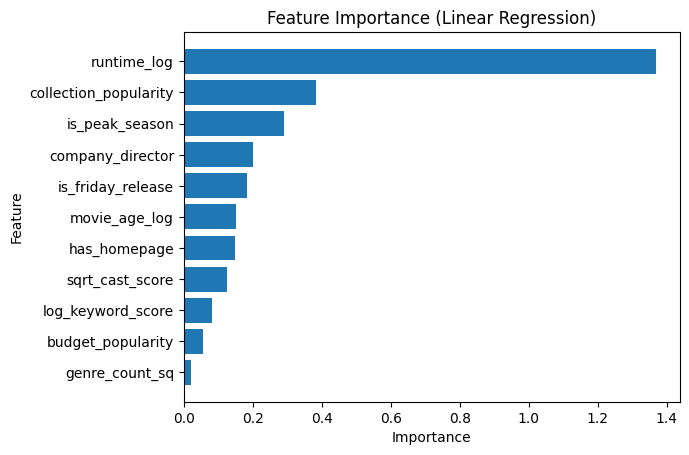

In [1278]:
coefficients = model.coef_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.abs(coefficients)
})

# Sort
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (Linear Regression)")
plt.gca().invert_yaxis()
plt.show()

In [1279]:
scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print(scores.mean())

0.4469893896023264


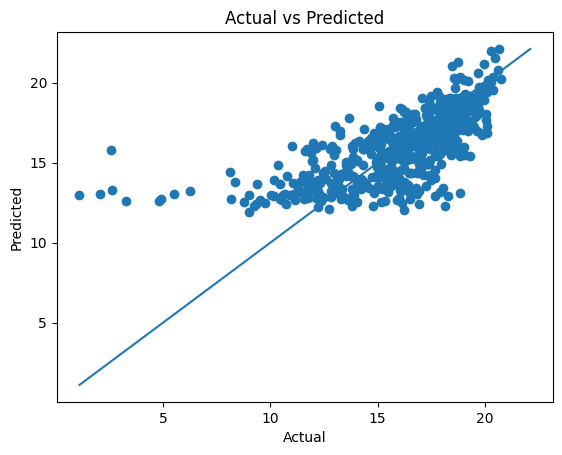

In [1280]:
plt.figure()
plt.scatter(y_test, y_pred)

# Diagonal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])  # y = x line

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

In [1319]:
top_features = feature_importance['Feature'].head(11)

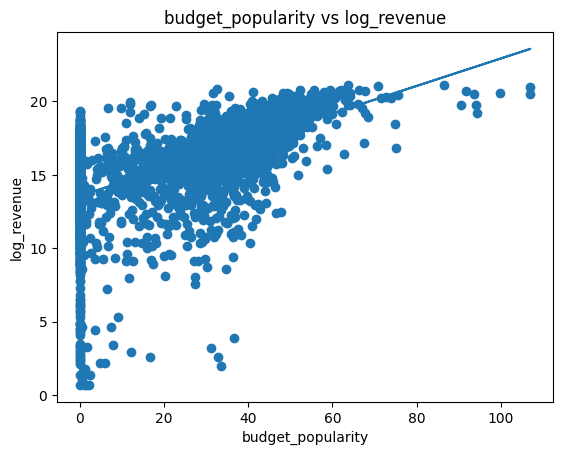

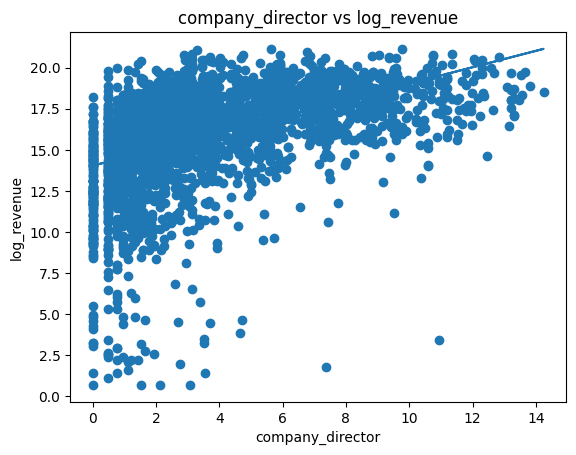

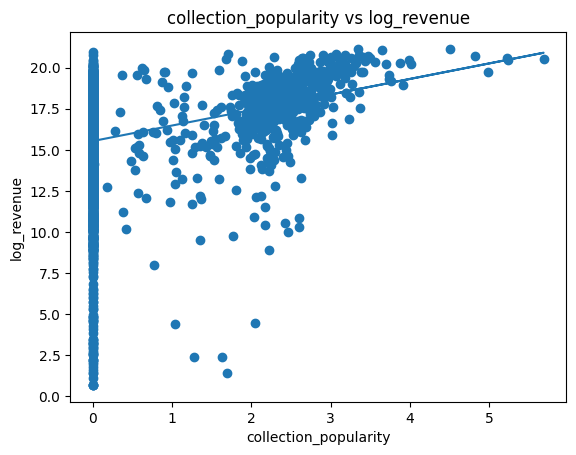

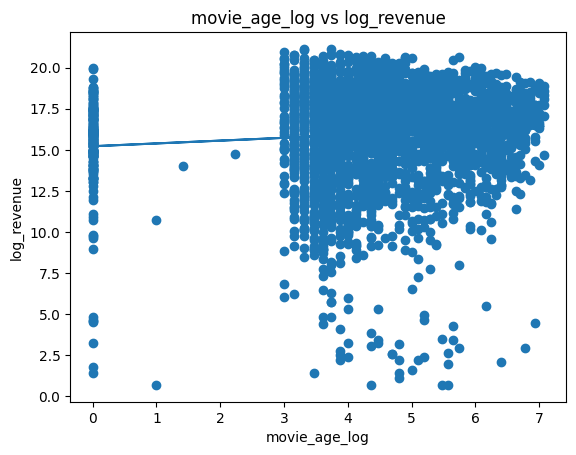

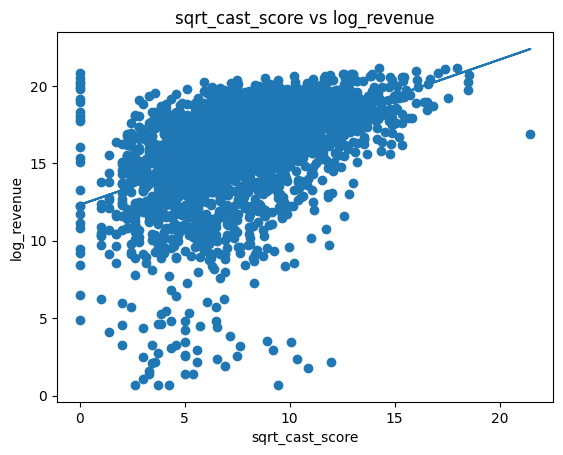

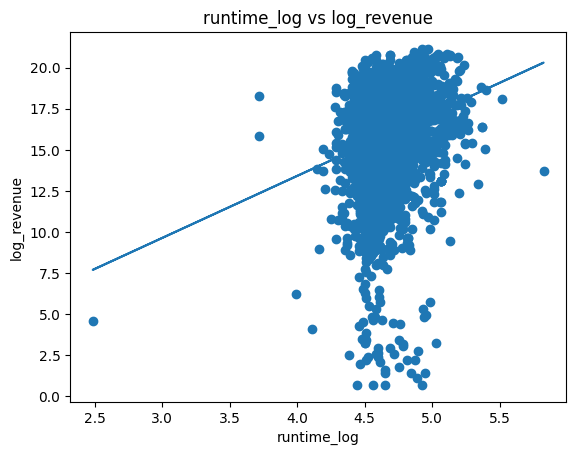

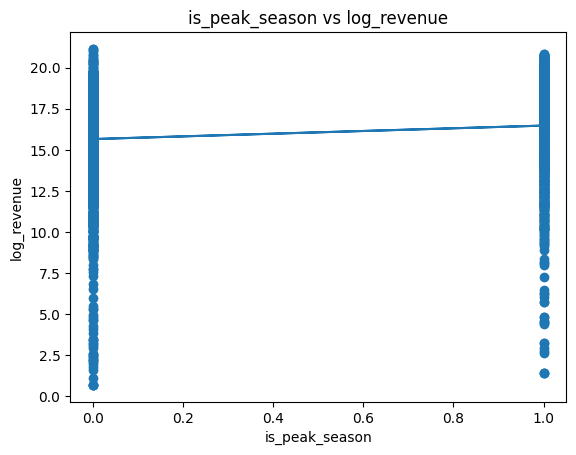

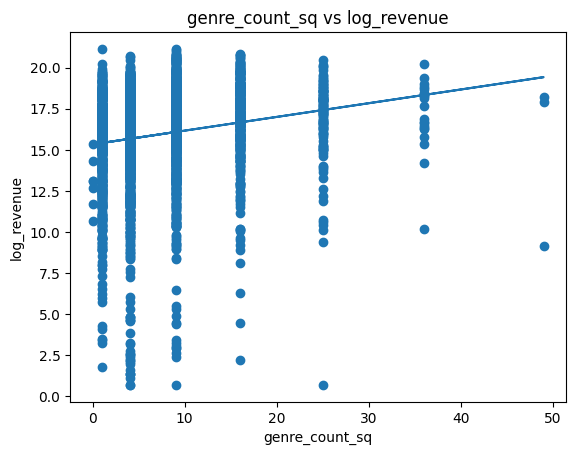

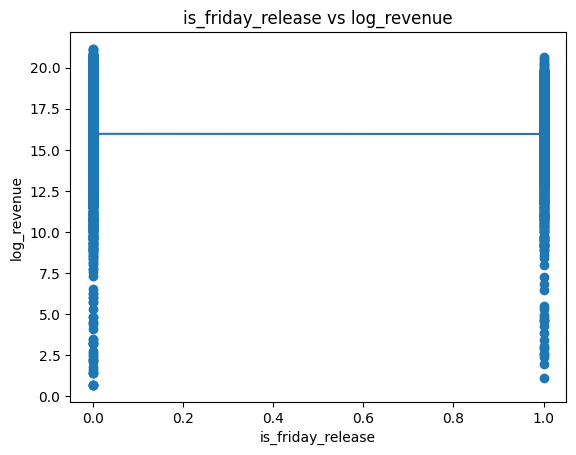

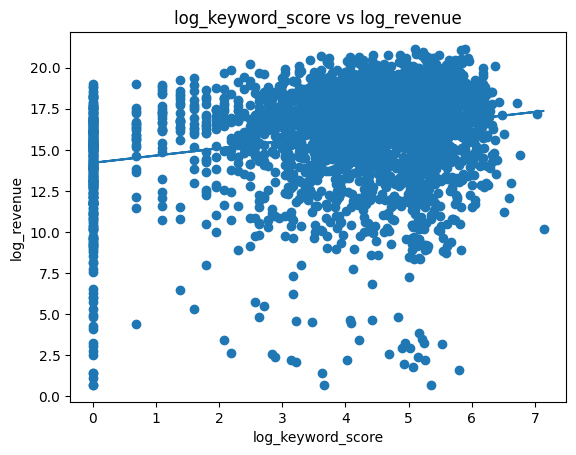

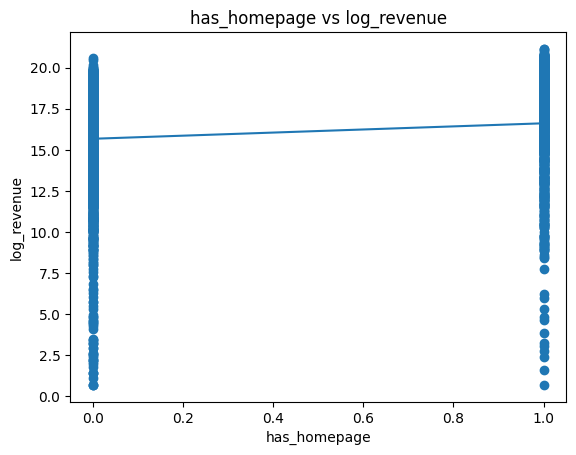

In [1320]:
for feature in top_features:
    plt.figure()
    plt.scatter(X[feature], y)

    # regression line
    z = np.polyfit(X[feature], y, 1)
    p = np.poly1d(z)

    plt.plot(X[feature], p(X[feature]))

    plt.xlabel(feature)
    plt.ylabel("log_revenue")
    plt.title(f"{feature} vs log_revenue")

    plt.show()

In [1321]:
X_train_top_feat=X_train[top_features]
X_test_top_feat=X_test[top_features]
X_train_top_feat.head()

,budget_popularity,company_director,collection_popularity,movie_age_log,sqrt_cast_score,runtime_log,is_peak_season,genre_count_sq,is_friday_release,log_keyword_score,has_homepage
642,38.072301,7.069916,0.0,6.164414,9.797959,4.762174,1,4,0,5.231109,0
700,36.271725,8.559184,0.0,6.324555,9.539392,4.553877,1,9,1,5.170484,0
226,38.286752,4.551699,0.0,3.872983,12.922848,4.663439,0,16,0,2.890372,1
1697,0.000000,5.452242,0.0,5.830952,8.774964,4.890349,0,9,1,4.897840,0
1010,50.505471,8.605838,0.0,3.316625,10.723805,4.836282,1,1,1,3.401197,0


In [1322]:
model_top_feat=LinearRegression()
model_top_feat.fit(X_train_top_feat, y_train)

LinearRegression()

In [1323]:
y_pred_top_feat = model_top_feat.predict(X_test_top_feat)

In [1324]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_top_feat))
r2 = r2_score(y_test, y_pred_top_feat)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 2.1578996138084214
R² Score: 0.47752281775567373


In [1325]:
X1=X[top_features]

scores = cross_val_score(model_top_feat, X1, y, cv=5, scoring='r2')
print(scores.mean())

0.44698938960232654


In [1283]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor( n_estimators=400,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [1284]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 2.027153046729232
R² Score: 0.5389182520517171


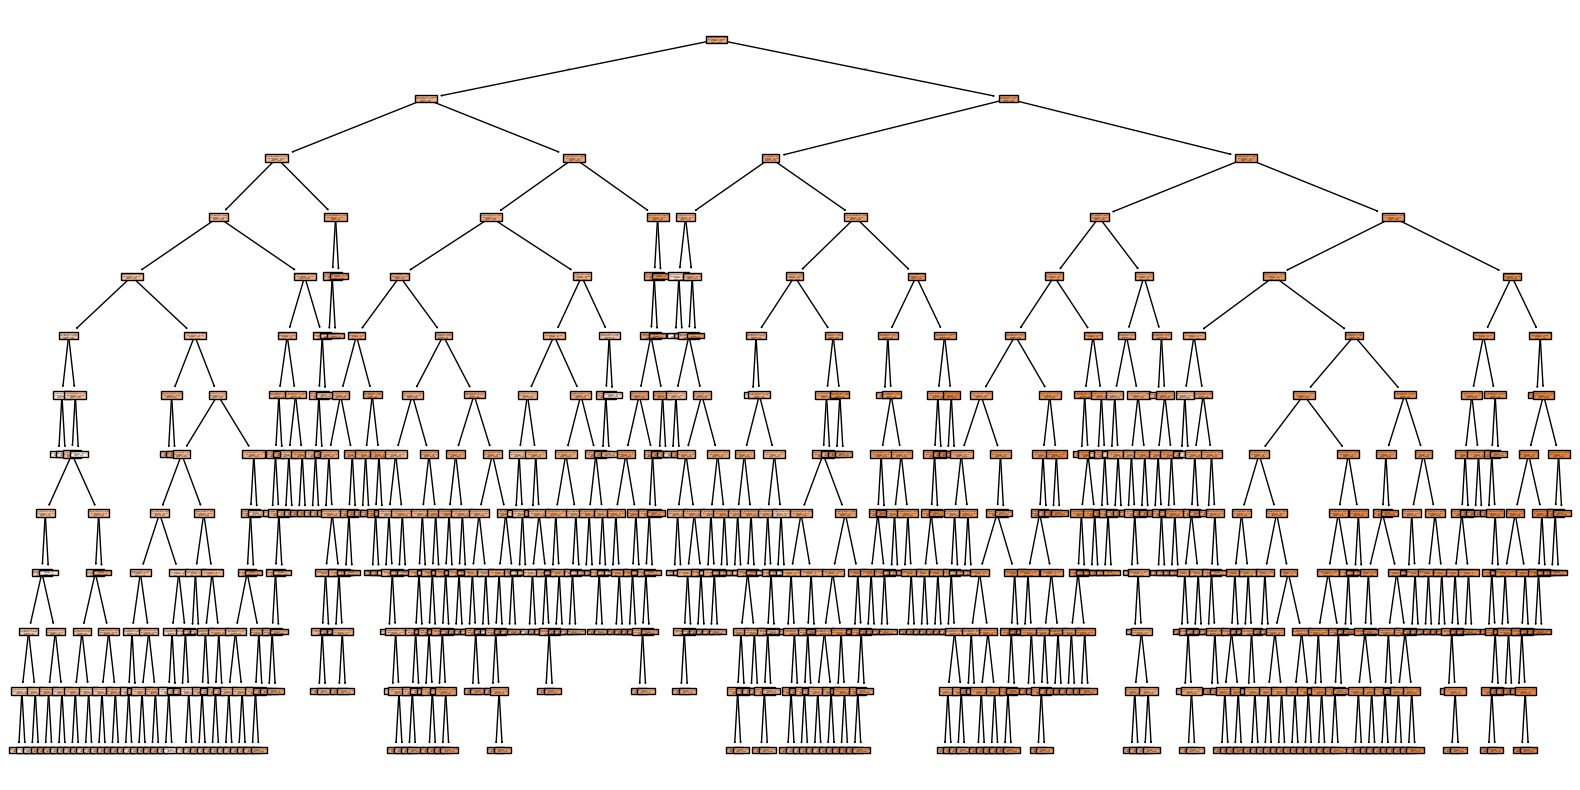

In [1285]:
# pick one tree
tree = model.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(tree, feature_names=X.columns, filled=True)
plt.show()

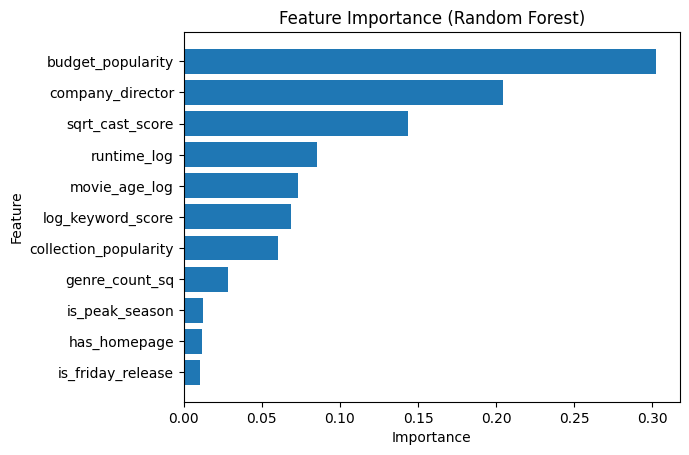

In [1286]:
# Get importance
importances = model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

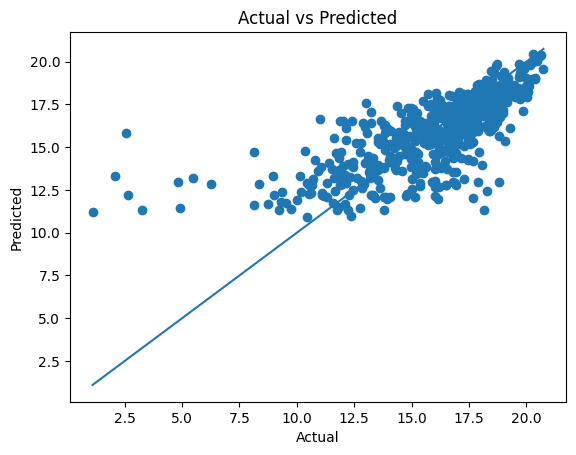

In [1287]:
plt.figure()
plt.scatter(y_test, y_pred)

# Diagonal line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])  # y = x line

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.show()

In [1288]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [1289]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 2.0298855634145343
R² Score: 0.5376743768280583


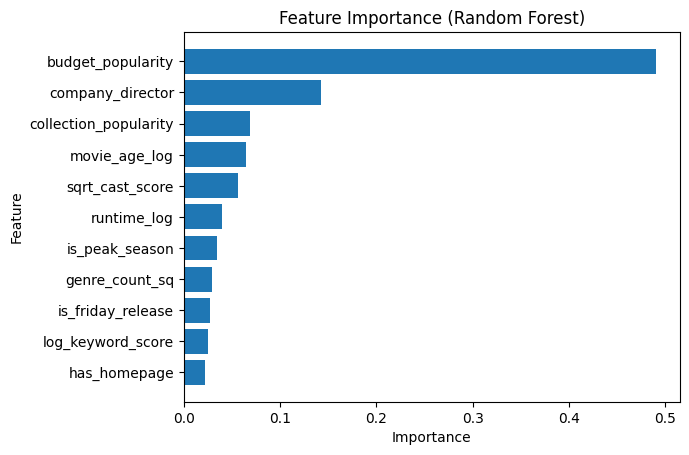

In [1290]:
# Get importance
importances = model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure()
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

In [1291]:
from sklearn.svm import SVR

model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [1292]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 2.131078477277053
R² Score: 0.49043013125883084


## base models
linear regression, random forest, xgboost